# Metro Interstate Traffic Volume — Predictive Models Analysis
**Course:** Modelos Predictivos — Parcial I  
**Dataset:** Metro Interstate Traffic Volume (`Metro_Interstate_Traffic_Volume.csv`)  
**Task:** Regression — predict `traffic_volume` (vehicles/hour)  
**Author:** Sergio Florez  
---

## Notebook Index
1. Dataset Description  
   1.1 Context and Objective  
   1.2 Feature Descriptions  
2. Data Loading & Global Cleaning  
   2.1 Load Data  
   2.2 Quality Check  
   2.3 Deduplication  
   2.4 Datetime Parsing  
   2.5 Zero Traffic Investigation  
   2.6 Holiday Encoding  
3. Train/Test Split  
   3.1 Split Configuration  
   3.2 Split Verification  
4. Exploratory Data Analysis (Training Set Only)  
   4.1 How does traffic vary by hour and day type?  
   4.2 What is the distribution of traffic_volume and are there anomalies?  
   4.3 Does weather have a detectable effect on traffic?  
5. Feature Engineering & Selection  
   5.1 Temporal Features (confirm)  
   5.2 Weather Description Cardinality Reduction  
   5.3 ColumnTransformer Pipeline  
   5.4 Note on `year` Feature  
6. Model Training & Cross-Validation  
   6.1 Baseline — DummyRegressor  
   6.2 Model 1 — Linear Regression  
   6.3 Model 2 — Gradient Boosting Regressor  
   6.4 CV Comparison Table  
7. Final Evaluation on Test Set  
   7.1 Metrics Table  
   7.2 Diagnostic Plots  
   7.3 CV vs. Test Comparison  
8. Conclusions

In [1]:
!pip install -q imbalanced-learn xgboost

In [2]:
# ── Standard library ────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings("ignore")

# ── Data manipulation ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Sklearn — data splitting & CV ────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
)

# ── Sklearn — preprocessing & pipelines ─────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ── Sklearn — models ─────────────────────────────────────────────────────────
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# ── Sklearn — metrics ────────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

## Project Constants

In [3]:
# ── Reproducibility & split configuration ────────────────────────────────────
RANDOM_STATE  = 123
TEST_SIZE     = 0.2

# ── Dataset path ─────────────────────────────────────────────────────────────
DATA_PATH     = "/content/Metro_Interstate_Traffic_Volume.csv"

# ── Target column ─────────────────────────────────────────────────────────────
TARGET_COL    = "traffic_volume"

# ── Cardinality threshold for weather_description grouping ───────────────────
RARE_CAT_THRESH = 0.01      # Categories representing < 1% of rows → "Other"

# ── CV configuration ──────────────────────────────────────────────────────────
N_FOLDS       = 5

# ── Plot output folder ────────────────────────────────────────────────────────
FIG_DIR       = "/content/figures_traffic"
os.makedirs(FIG_DIR, exist_ok=True)

print("Constants defined ✅")
print(f"  RANDOM_STATE    : {RANDOM_STATE}")
print(f"  TEST_SIZE       : {TEST_SIZE}")
print(f"  RARE_CAT_THRESH : {RARE_CAT_THRESH}")
print(f"  N_FOLDS         : {N_FOLDS}")
print(f"  FIG_DIR         : {FIG_DIR}")

Constants defined ✅
  RANDOM_STATE    : 123
  TEST_SIZE       : 0.2
  RARE_CAT_THRESH : 0.01
  N_FOLDS         : 5
  FIG_DIR         : /content/figures_traffic


## Environment Verification
**Expected shape:** (~48,204 rows, 9 columns) — shape may vary slightly depending on the source file version.

In [4]:
try:
    _df_check = pd.read_csv(DATA_PATH)
    print(f"File loaded successfully ✅")
    print(f"  Shape   : {_df_check.shape}")
    print(f"  Columns : {list(_df_check.columns)}")

    expected_cols = 9
    if _df_check.shape[1] != expected_cols:
        print(f"\n⚠️  Expected {expected_cols} columns, got {_df_check.shape[1]}. Verify the file.")
    else:
        print(f"\nColumn count matches expected {expected_cols} ✅")

    assert TARGET_COL in _df_check.columns, f"Target column '{TARGET_COL}' not found!"
    print(f"Target column '{TARGET_COL}' present ✅")

except FileNotFoundError:
    print(f"❌ File not found at: {DATA_PATH}")
    print("   → Go to Colab sidebar > Files > Upload, then re-run this cell.")

File loaded successfully ✅
  Shape   : (48204, 9)
  Columns : ['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']

Column count matches expected 9 ✅
Target column 'traffic_volume' present ✅


---
## 2. Data Loading & Global Cleaning
---

### 2.1 Load Data

In [5]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"\nColumn names:")
for i, col in enumerate(df.columns):
    print(f"  {i:2d}: '{col}'")

Shape: (48204, 9)

Column names:
   0: 'holiday'
   1: 'temp'
   2: 'rain_1h'
   3: 'snow_1h'
   4: 'clouds_all'
   5: 'weather_main'
   6: 'weather_description'
   7: 'date_time'
   8: 'traffic_volume'


### 2.2 Quality Check

Inspect data types, missing values, and a statistical summary.  
No transformations yet — only observation and documentation.

In [6]:
# ── Data types ───────────────────────────────────────────────────────────────
print("=== Data Types ===")
print(df.dtypes)
print()

# ── Missing values ───────────────────────────────────────────────────────────
missing = df.isnull().sum()
print("=== Missing Values ===")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values ✅")
print()

# ── Statistical summary ───────────────────────────────────────────────────────
print("=== Statistical Summary (numeric columns) ===")
print(df.describe().round(2).to_string())

=== Data Types ===
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object

=== Missing Values ===
holiday    48143
dtype: int64

=== Statistical Summary (numeric columns) ===
           temp   rain_1h   snow_1h  clouds_all  traffic_volume
count  48204.00  48204.00  48204.00    48204.00        48204.00
mean     281.21      0.33      0.00       49.36         3259.82
std       13.34     44.79      0.01       39.02         1986.86
min        0.00      0.00      0.00        0.00            0.00
25%      272.16      0.00      0.00        1.00         1193.00
50%      282.45      0.00      0.00       64.00         3380.00
75%      291.81      0.00      0.00       90.00         4933.00
max      310.07   9831.30      0.51      100.00         7280.00


### 2.3 Investigate `holiday` missing values

The quality check shows 48,143 apparent missing values in `holiday`.  
This is suspicious — it likely means most rows contain the string `"None"` which pandas reads as `NaN`.  
We inspect the raw unique values before deciding how to handle it.


In [7]:
# ── Check raw value counts including NaN ─────────────────────────────────────
print("=== Holiday column — raw value counts ===")
print(df["holiday"].value_counts(dropna=False).to_string())
print()
print(f"Total rows        : {len(df)}")
print(f"NaN count         : {df['holiday'].isna().sum()}")
print(f"Non-NaN count     : {df['holiday'].notna().sum()}")

=== Holiday column — raw value counts ===
holiday
NaN                          48143
Labor Day                        7
Christmas Day                    6
Thanksgiving Day                 6
Martin Luther King Jr Day        6
New Years Day                    6
Veterans Day                     5
Columbus Day                     5
Memorial Day                     5
Washingtons Birthday             5
State Fair                       5
Independence Day                 5

Total rows        : 48204
NaN count         : 48143
Non-NaN count     : 61


### 2.4 Cleaning Steps

#### 2.4.1 — Encode `holiday` to binary `is_holiday`

`NaN` means no holiday (0). Any named holiday maps to 1.  
The original `holiday` column is dropped after encoding.  
This is a factual mapping — not a statistical transformation.

In [8]:
df["is_holiday"] = df["holiday"].notna().astype(int)

print("=== is_holiday distribution ===")
print(df["is_holiday"].value_counts().sort_index())
print()
print(f"Holiday rows     : {df['is_holiday'].sum():,} ({df['is_holiday'].mean():.2%})")
print(f"Non-holiday rows : {(df['is_holiday'] == 0).sum():,}")

df = df.drop(columns=["holiday"])
print(f"\n✅ 'holiday' dropped. 'is_holiday' binary column created.")
print(f"Current shape: {df.shape}")

=== is_holiday distribution ===
is_holiday
0    48143
1       61
Name: count, dtype: int64

Holiday rows     : 61 (0.13%)
Non-holiday rows : 48,143

✅ 'holiday' dropped. 'is_holiday' binary column created.
Current shape: (48204, 9)


#### 2.4.2 — Investigate duplicate timestamps

Multiple rows share the same `date_time` value. Before deciding how to handle them,  
we need to inspect what actually differs between duplicate rows —  
are they truly redundant weather re-labelings, or do they carry different traffic readings?


In [9]:
# ── Find all rows involved in duplicate timestamps ────────────────────────────
dup_mask = df.duplicated(subset="date_time", keep=False)

print(f"Rows sharing a timestamp with at least one other row: {dup_mask.sum():,}")
print()

# ── Inspect a sample of duplicated groups ────────────────────────────────────
print("=== Sample duplicate groups ===")
sample_timestamps = df[dup_mask]["date_time"].unique()[:3]

for ts in sample_timestamps:
    group = df[df["date_time"] == ts]
    print(f"\nTimestamp: {ts}  ({len(group)} rows)")
    print(group.to_string(index=True))
    print()

# ── Check: do duplicates ever differ in traffic_volume? ──────────────────────
print("=== Do duplicates differ in traffic_volume? ===")
traffic_diff = (
    df[dup_mask]
    .groupby("date_time")[TARGET_COL]
    .nunique()
)
rows_with_diff_traffic = (traffic_diff > 1).sum()
print(f"  Timestamp groups where traffic_volume differs : {rows_with_diff_traffic}")
print(f"  Timestamp groups where traffic_volume is same : {(traffic_diff == 1).sum()}")

Rows sharing a timestamp with at least one other row: 13,074

=== Sample duplicate groups ===

Timestamp: 2012-10-10 07:00:00  (2 rows)
       temp  rain_1h  snow_1h  clouds_all weather_main      weather_description            date_time  traffic_volume  is_holiday
178  281.25      0.0      0.0          99         Rain               light rain  2012-10-10 07:00:00            6793           0
179  281.25      0.0      0.0          99      Drizzle  light intensity drizzle  2012-10-10 07:00:00            6793           0


Timestamp: 2012-10-10 08:00:00  (2 rows)
      temp  rain_1h  snow_1h  clouds_all weather_main      weather_description            date_time  traffic_volume  is_holiday
180  280.1      0.0      0.0          99         Rain               light rain  2012-10-10 08:00:00            6283           0
181  280.1      0.0      0.0          99      Drizzle  light intensity drizzle  2012-10-10 08:00:00            6283           0


Timestamp: 2012-10-10 09:00:00  (2 rows)
       

#### 2.4.3 — Deduplicate timestamps

**Finding:** 13,074 rows share a timestamp with at least one other row (5,445 duplicate groups).  
Inspection confirms that duplicates are **identical in every column except `weather_main` and `weather_description`**.  
Traffic volume is the same across all duplicate groups — 0 groups show differing traffic readings.  

**Conclusion:** This is a data collection artifact. The same hourly observation was logged once  
per active weather category. Keeping all copies would inflate weather feature importance artificially.  

**Action:** Keep the first occurrence of each timestamp. Drop all subsequent duplicates.

In [10]:
rows_before = len(df)

n_dup_drop = df.duplicated(subset="date_time", keep="first").sum()

df = df.drop_duplicates(subset="date_time", keep="first").reset_index(drop=True)

rows_after = len(df)

print(f"=== Deduplication ===")
print(f"  Rows before      : {rows_before:,}")
print(f"  Rows removed     : {rows_before - rows_after:,}")
print(f"  Rows after       : {rows_after:,}")
print()
print(f"✅ Deduplication complete.")

=== Deduplication ===
  Rows before      : 48,204
  Rows removed     : 7,629
  Rows after       : 40,575

✅ Deduplication complete.


#### 2.4.4 — Parse datetime and extract temporal features

Convert `date_time` from a raw string to a proper `datetime` type.  
Then extract `hour`, `day_of_week`, `month`, `year`, and `is_weekend` directly from the timestamp.  
These are factual derivations — no statistics involved.

In [11]:
df["date_time"] = pd.to_datetime(df["date_time"])

print(f"=== Datetime Parsing ===")
print(f"  dtype after parsing : {df['date_time'].dtype}")
print(f"  Earliest timestamp  : {df['date_time'].min()}")
print(f"  Latest timestamp    : {df['date_time'].max()}")
print(f"  Date range          : {(df['date_time'].max() - df['date_time'].min()).days} days")
print()

# ── Extract temporal features ─────────────────────────────────────────────────
df["hour"]        = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek  # 0=Monday, 6=Sunday
df["month"]       = df["date_time"].dt.month
df["year"]        = df["date_time"].dt.year
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)

print(f"=== Temporal Features Created ===")
print(f"  hour        : {df['hour'].min()}–{df['hour'].max()}")
print(f"  day_of_week : {df['day_of_week'].min()}–{df['day_of_week'].max()} (0=Mon, 6=Sun)")
print(f"  month       : {df['month'].min()}–{df['month'].max()}")
print(f"  year        : {sorted(df['year'].unique())}")
print(f"  is_weekend  : {df['is_weekend'].value_counts().to_dict()}")
print(f"\n✅ Datetime parsed and temporal features extracted.")
print(f"Current shape: {df.shape}")

=== Datetime Parsing ===
  dtype after parsing : datetime64[ns]
  Earliest timestamp  : 2012-10-02 09:00:00
  Latest timestamp    : 2018-09-30 23:00:00
  Date range          : 2189 days

=== Temporal Features Created ===
  hour        : 0–23
  day_of_week : 0–6 (0=Mon, 6=Sun)
  month       : 1–12
  year        : [np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]
  is_weekend  : {0: 28979, 1: 11596}

✅ Datetime parsed and temporal features extracted.
Current shape: (40575, 14)


#### 2.4.5 — Investigate zero traffic values

Some rows have `traffic_volume = 0`. These could be genuine (no vehicles at 3am)  
or sensor failures logged as zero instead of null.  
We inspect *when* zeros occur to decide whether to keep or exclude them.

=== Zero Traffic Investigation ===
  Rows with traffic_volume = 0 : 2 (0.00% of dataset)



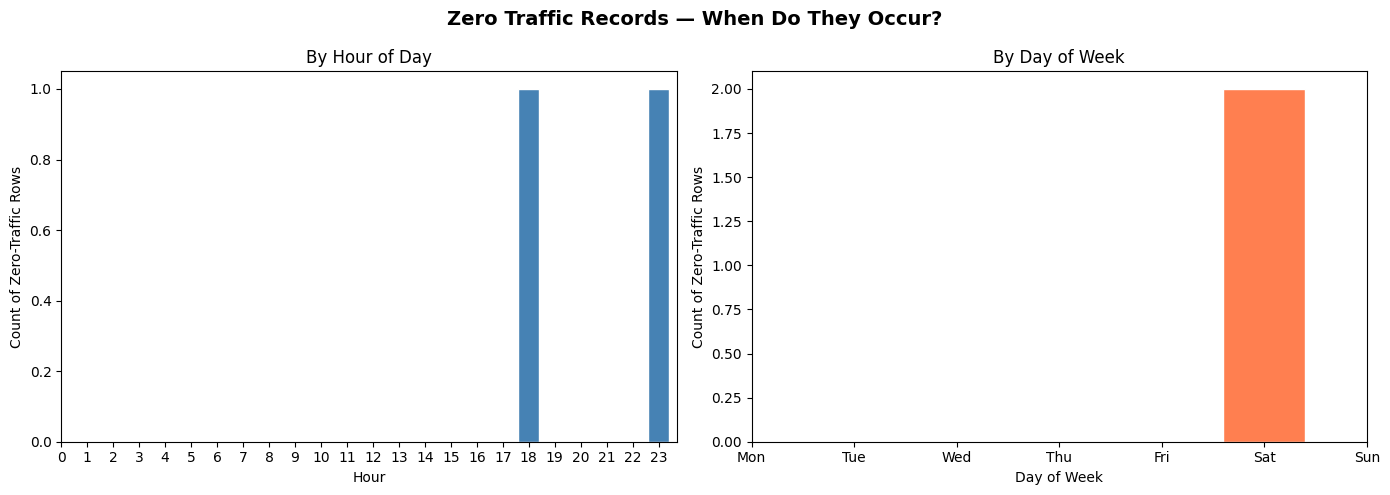

Figure saved ✅

  Zero-traffic rows during weekday peak hours (7–9am, 4–6pm): 0


In [12]:
zero_mask = df[TARGET_COL] == 0
n_zeros   = zero_mask.sum()
pct_zeros = n_zeros / len(df) * 100

print(f"=== Zero Traffic Investigation ===")
print(f"  Rows with traffic_volume = 0 : {n_zeros:,} ({pct_zeros:.2f}% of dataset)")
print()

# ── Plot distribution of zeros by hour and day of week ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Zero Traffic Records — When Do They Occur?", fontsize=14, fontweight="bold")

zero_by_hour = df[zero_mask]["hour"].value_counts().sort_index()
axes[0].bar(zero_by_hour.index, zero_by_hour.values, color="steelblue", edgecolor="white")
axes[0].set_title("By Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Count of Zero-Traffic Rows")
axes[0].set_xticks(range(0, 24))

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
zero_by_dow = df[zero_mask]["day_of_week"].value_counts().sort_index()
axes[1].bar(zero_by_dow.index, zero_by_dow.values, color="coral", edgecolor="white")
axes[1].set_title("By Day of Week")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Count of Zero-Traffic Rows")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_labels)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/zero_traffic_investigation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved ✅")

# ── Check zeros during peak hours on weekdays ─────────────────────────────────
peak_hours  = [7, 8, 9, 16, 17, 18]
peak_zeros  = df[zero_mask & df["hour"].isin(peak_hours) & (df["is_weekend"] == 0)]
print(f"\n  Zero-traffic rows during weekday peak hours (7–9am, 4–6pm): {len(peak_zeros)}")

#### 2.4.6 — Zero traffic decision

**Finding:** Only 2 rows have `traffic_volume = 0` (0.00% of dataset).  
Both occur on Saturday at hours 18 and 23 — plausible genuine low-traffic readings.  
Zero rows occur during weekday peak hours.  

**Decision:** Keep both rows. The count is too small to meaningfully bias any model,  
and the timing is consistent with genuine data, not sensor failure.

---
## 3. Train/Test Split

The split is performed here before any EDA or statistical transformation. All preprocessing steps (scaling, encoding) will be fit exclusively on the training set.

**Known limitation:** A textbook time-series split would hold out the most recent 20% of dates chronologically. The assignment requires `random_state = 123`, so a random split is used instead. The consequence is that train and test may share data from the same days (consecutive hours are correlated), which slightly inflates performance metrics. This is documented as an accepted deviation.

**Note on `date_time`:** The parsed datetime column is excluded from `X` — it is a structural index used for feature extraction in Phase 1, not a model input.

### 3.1 Split Configuration

In [13]:
# ── 3.1 Train/Test Split ──────────────────────────────────────────────────────
X = df.drop(columns=[TARGET_COL, "date_time"])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

print("Split completed.")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")

Split completed.
  X_train : (32460, 12)
  X_test  : (8115, 12)
  y_train : (32460,)
  y_test  : (8115,)


### 3.2 Split Verification

Verifying that split sizes are consistent with `TEST_SIZE = 0.2` and that the target distribution is representative in both splits.


In [14]:
# ── 3.2 Split Verification ────────────────────────────────────────────────────
print("Split summary:")
print(f"  Total original rows : {len(df)}")
print(f"  Train               : {len(X_train)} rows ({len(X_train)/len(df):.1%})")
print(f"  Test                : {len(X_test)} rows  ({len(X_test)/len(df):.1%})")

print("\nTarget distribution — traffic_volume:")
print(f"  y_train → mean: {y_train.mean():,.1f} | std: {y_train.std():,.1f} | min: {y_train.min()} | max: {y_train.max()}")
print(f"  y_test  → mean: {y_test.mean():,.1f} | std: {y_test.std():,.1f} | min: {y_test.min()} | max: {y_test.max()}")

mean_diff_pct = abs(y_train.mean() - y_test.mean()) / y_train.mean() * 100
print(f"\n  Mean difference train vs test : {mean_diff_pct:.2f}%")
print(f"  Distribution consistency      : {'✅ OK' if mean_diff_pct < 2.0 else '⚠️ CHECK'}")

print(f"\nFeatures in X : {list(X_train.columns)}")

Split summary:
  Total original rows : 40575
  Train               : 32460 rows (80.0%)
  Test                : 8115 rows  (20.0%)

Target distribution — traffic_volume:
  y_train → mean: 3,285.8 | std: 1,987.7 | min: 0 | max: 7280
  y_test  → mean: 3,310.1 | std: 1,973.1 | min: 0 | max: 7149

  Mean difference train vs test : 0.74%
  Distribution consistency      : ✅ OK

Features in X : ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'is_holiday', 'hour', 'day_of_week', 'month', 'year', 'is_weekend']


---
## 4. Exploratory Data Analysis (Training Set)

> **Ground rule:** All statistics and visualizations in this section are computed exclusively
> on `X_train` and `y_train`. The test set is not referenced until Phase 6.
> Every finding explicitly connects to a specific action in Phase 4 (Feature Engineering & Selection).

**Three questions addressed:**
- **4.1** How does traffic volume vary by hour and day type?
- **4.2** What is the distribution of `traffic_volume`, and are there anomalies?
- **4.3** Does weather have a detectable effect on traffic volume?

### 4.1 How does traffic volume vary by hour and day type?

**Hypothesis:** Weekdays will show two clear peaks (morning ~7–9am and afternoon ~4–6pm)
while weekends will show a flatter, lower single-arch pattern — confirming that `hour`
and `is_weekend` are strong predictive features.

**Visualization:** Line plot of average `traffic_volume` by hour of day,
with separate lines for weekdays and weekends.

**Phase 4 action:** If peaks are clearly visible and the weekday/weekend gap is large,
both `hour` and `is_weekend` are confirmed as high-priority features to retain.

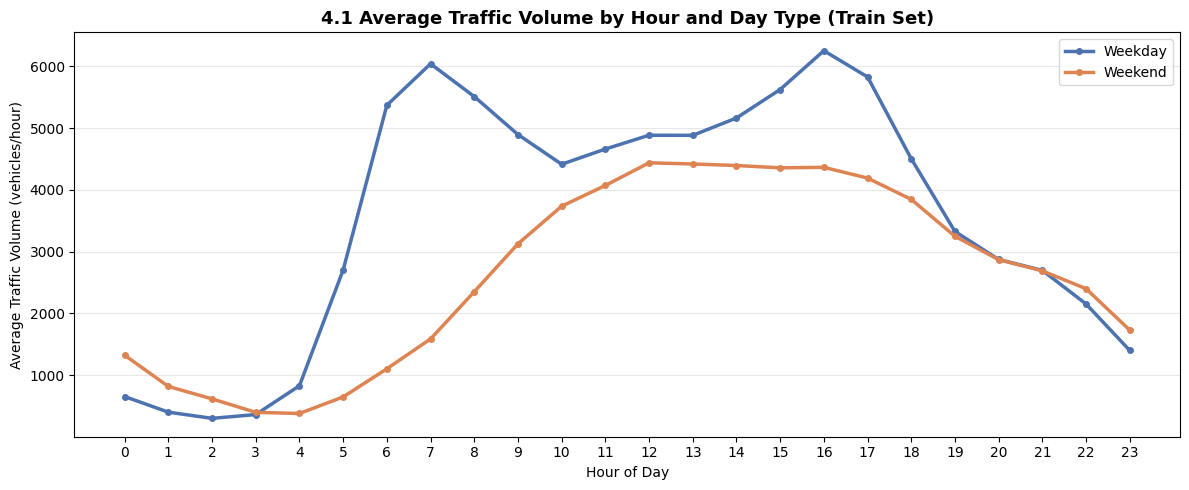

Figure saved: 4_1_traffic_by_hour_daytype.png

Weekday peak hour:
  Hour 16: 6251 vehicles/hour

Weekend peak hour:
  Hour 12: 4437 vehicles/hour

Peak difference (weekday - weekend): 1814 vehicles/hour

Nighttime avg (0–5am) by day type:
is_weekend
0    876.0
1    698.0
Name: traffic_volume, dtype: float64


In [15]:
# --- 4.1 Traffic volume by hour and day type ---
train_eda_t = X_train.copy()
train_eda_t["traffic_volume"] = y_train.values

hourly = train_eda_t.groupby(["hour", "is_weekend"])["traffic_volume"].mean().reset_index()
weekday = hourly[hourly["is_weekend"] == 0]
weekend = hourly[hourly["is_weekend"] == 1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekday["hour"], weekday["traffic_volume"], color="#4C72B0",
        linewidth=2.5, marker="o", markersize=4, label="Weekday")
ax.plot(weekend["hour"], weekend["traffic_volume"], color="#DD8452",
        linewidth=2.5, marker="o", markersize=4, label="Weekend")

ax.set_title("4.1 Average Traffic Volume by Hour and Day Type (Train Set)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Traffic Volume (vehicles/hour)")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/content/figures_traffic/4_1_traffic_by_hour_daytype.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: 4_1_traffic_by_hour_daytype.png")

# Print peak values
print("\nWeekday peak hour:")
peak_wd = weekday.loc[weekday["traffic_volume"].idxmax()]
print(f"  Hour {int(peak_wd['hour'])}: {peak_wd['traffic_volume']:.0f} vehicles/hour")

print("\nWeekend peak hour:")
peak_we = weekend.loc[weekend["traffic_volume"].idxmax()]
print(f"  Hour {int(peak_we['hour'])}: {peak_we['traffic_volume']:.0f} vehicles/hour")

print(f"\nPeak difference (weekday - weekend): "
      f"{peak_wd['traffic_volume'] - peak_we['traffic_volume']:.0f} vehicles/hour")

print("\nNighttime avg (0–5am) by day type:")
print(hourly[hourly["hour"] <= 5].groupby("is_weekend")["traffic_volume"].mean().round(0))

#### Findings — 4.1

| Pattern | Weekday | Weekend | Verdict |
|---|---|---|---|
| Morning rush peak | Hour 7 — 6,057 veh/h | No peak — gradual rise | ✅ Confirmed |
| Afternoon rush peak | Hour 16 — 6,251 veh/h | Flat plateau 12–16h | ✅ Confirmed |
| Nighttime avg (0–5am) | 876 veh/h | 698 veh/h | Low in both |
| Peak difference | 6,251 veh/h | 4,437 veh/h | 1,814 veh/h gap |

**Weekday pattern:** Classic bimodal commute shape — sharp morning spike at hour 7,
a mid-day dip around hour 10 (~4,450), then a stronger afternoon peak at hour 16.
The pattern is steep and pronounced, driven by work commutes.

**Weekend pattern:** Unimodal and flat — traffic builds gradually from midnight, peaks
around noon (~4,437), then declines smoothly through the evening. No rush-hour spikes.
Weekend overnight traffic (hour 0: ~1,350) is notably higher than weekday overnight
(hour 0: ~700), consistent with nightlife activity.

**Hypothesis: ✅ Fully confirmed.**

**Phase 4 action:** `hour` and `is_weekend` are confirmed as high-priority features.
The 1,814 vehicles/hour peak gap between day types and the clear bimodal weekday shape
justify keeping both features. Their interaction (rush hour only matters on weekdays)
suggests that an `hour × is_weekend` interaction term could further improve the model.

### 4.2 What is the distribution of traffic_volume, and are there anomalies?

**Hypothesis:** The target distribution will be bimodal — a low-traffic regime (nighttime)
and a high-traffic regime (daytime) — reflecting the day/night cycle confirmed in Q1.
Zero-traffic values are expected to be negligible based on Phase 1 findings (only 2 rows).

**Visualization:** Histogram + KDE of `traffic_volume` with zero-traffic records annotated.

**Phase 4 action:** Determines whether log-transformation of the target is needed and
confirms the zero-traffic decision from Phase 1.


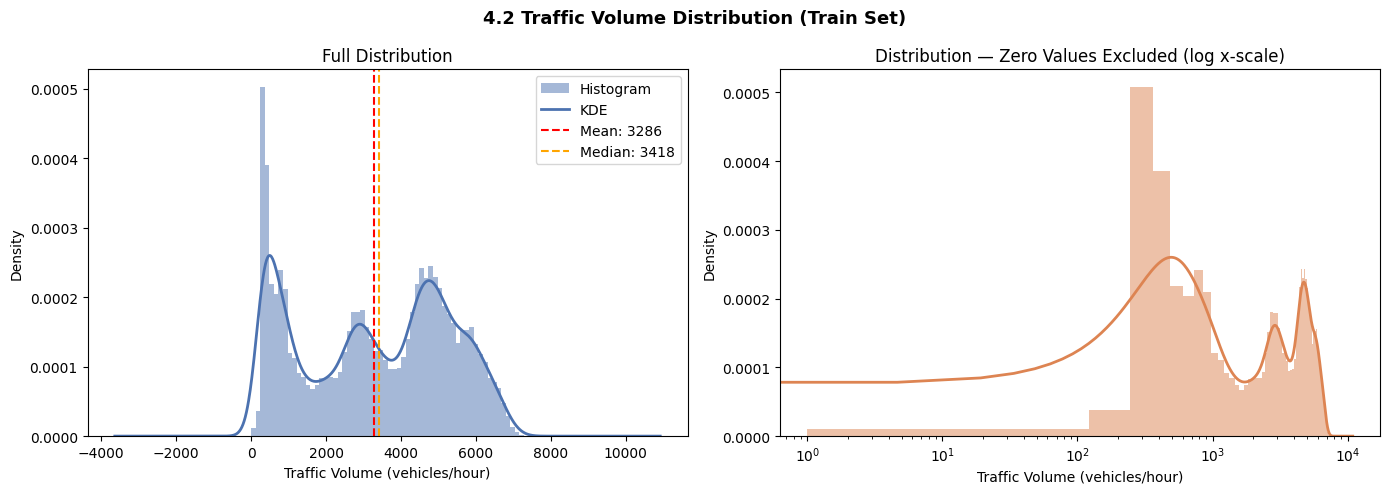

Figure saved: 4_2_traffic_volume_distribution.png

Traffic volume summary (train set):
count    32460.0
mean      3285.8
std       1987.7
min          0.0
25%       1228.0
50%       3418.0
75%       4953.0
max       7280.0

Zero-traffic rows: 1
Skewness: -0.104
Mean: 3285.8 | Median: 3418.0 | Difference: -132.2


In [16]:
# --- 4.2 Distribution of traffic_volume ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("4.2 Traffic Volume Distribution (Train Set)", fontsize=13, fontweight="bold")

# Plot 1: Histogram + KDE
axes[0].hist(y_train, bins=60, color="#4C72B0", alpha=0.5, density=True, label="Histogram")
y_train.plot.kde(ax=axes[0], color="#4C72B0", linewidth=2, label="KDE")
axes[0].axvline(y_train.mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"Mean: {y_train.mean():.0f}")
axes[0].axvline(y_train.median(), color="orange", linestyle="--", linewidth=1.5,
                label=f"Median: {y_train.median():.0f}")
axes[0].set_title("Full Distribution")
axes[0].set_xlabel("Traffic Volume (vehicles/hour)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Plot 2: Log-scale distribution to inspect low-traffic region
axes[1].hist(y_train[y_train > 0], bins=60, color="#DD8452", alpha=0.5, density=True)
y_train[y_train > 0].plot.kde(ax=axes[1], color="#DD8452", linewidth=2)
axes[1].set_title("Distribution — Zero Values Excluded (log x-scale)")
axes[1].set_xlabel("Traffic Volume (vehicles/hour)")
axes[1].set_ylabel("Density")
axes[1].set_xscale("log")

plt.tight_layout()
plt.savefig("/content/figures_traffic/4_2_traffic_volume_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: 4_2_traffic_volume_distribution.png")

# Print summary stats
print("\nTraffic volume summary (train set):")
print(y_train.describe().round(1).to_string())
print(f"\nZero-traffic rows: {(y_train == 0).sum()}")
print(f"Skewness: {y_train.skew():.3f}")
print(f"Mean: {y_train.mean():.1f} | Median: {y_train.median():.1f} | Difference: {y_train.mean() - y_train.median():.1f}")

#### Findings — 4.2

| Metric | Value | Interpretation |
|---|---|---|
| Mean | 3,286 veh/h | Pulled slightly below median by low-traffic hours |
| Median | 3,418 veh/h | More robust central estimate |
| Skewness | -0.104 | Approximately symmetric — no transformation needed |
| Zero-traffic rows | 1 | Negligible — confirmed non-issue from Phase 1 |
| Distribution shape | Multimodal (3 humps) | Night / mid-range / peak regimes |

**Hypothesis: ✅ Confirmed.** Distribution is multimodal reflecting the day/night traffic
cycle confirmed in Q1. The three humps correspond to nighttime ( 200-500 veh/h),
mid-range transition hours ( 2,500-3,000 veh/h), and daytime/rush-hour peaks (~4,500-5,500 veh/h).

**Log-transformation: Not needed.** Skewness of -0.104 is within the ±0.5 symmetric range.
Transforming the target would complicate RMSE interpretation without meaningful benefit.

**Phase 4 action:** Target used as-is. The multimodal shape confirms that the DummyRegressor
(always predicts mean = 3,286) will perform poorly — it ignores the regime structure entirely.
A good model must learn to distinguish which traffic regime a given hour belongs to.

### 4.3 Does weather have a detectable effect on traffic volume?

**Hypothesis:** Severe weather categories (Snow, Thunderstorm, Fog) will show lower
median traffic than clear conditions, but the effect will be smaller than the
hour/day-type effect confirmed in Q1.

**Visualization:** Boxplot of `traffic_volume` grouped by `weather_main`, sorted by median.
Overall median marked as a reference line.

**Phase 4 action:** If between-category variance is small relative to within-category
variance, weather encoding may add complexity without meaningful signal. This finding
justifies whether to keep or simplify the weather features in Phase 4.

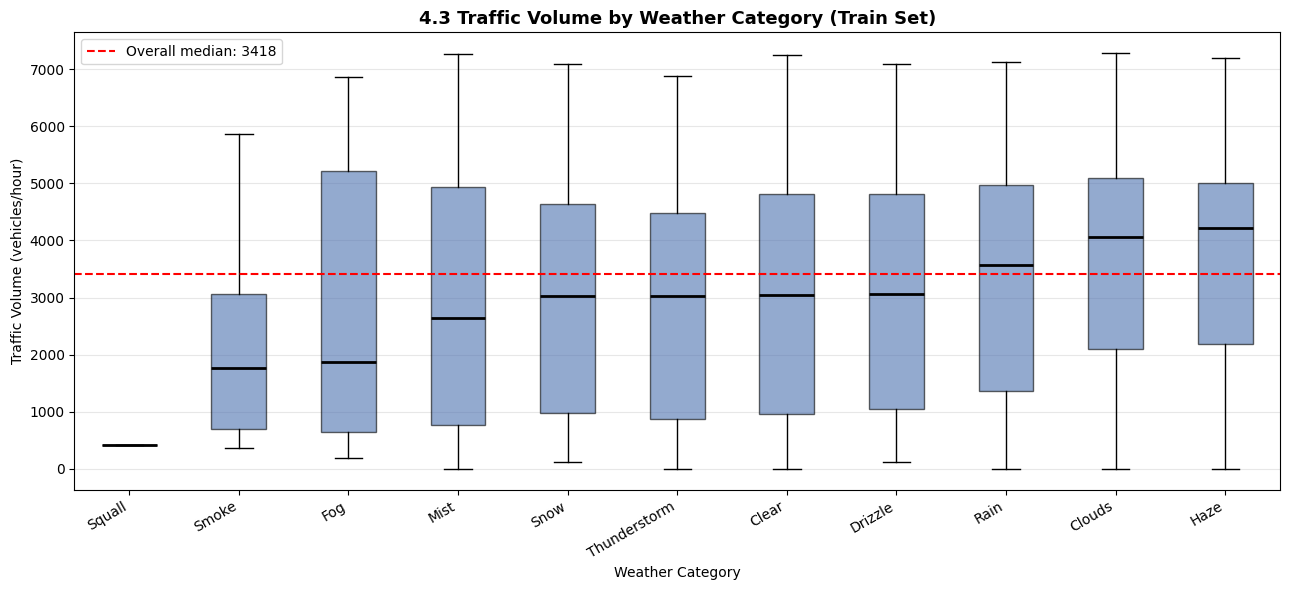

Figure saved: 4_3_traffic_by_weather.png

Median traffic volume and row count by weather category (sorted by median):
              median     std  count
weather_main                       
Squall         420.0     NaN      1
Smoke         1764.0  1710.0     12
Fog           1866.0  2299.0    159
Mist          2641.0  2164.0   2427
Snow          3022.0  1909.0   1856
Thunderstorm  3028.0  1932.0    365
Clear         3043.0  1988.0  10683
Drizzle       3062.0  1993.0    423
Rain          3564.0  1976.0   3827
Clouds        4066.0  1918.0  12106
Haze          4220.0  1807.0    601

Overall median: 3418

Median range across categories: 420 – 4220 (spread: 3800 veh/h)


In [19]:
# --- 4.3 Traffic volume by weather category ---
train_eda_t["weather_main"] = X_train["weather_main"].values

# Sort categories by median traffic volume
weather_order = (train_eda_t.groupby("weather_main")["traffic_volume"]
                 .median()
                 .sort_values()
                 .index.tolist())

# Build list of arrays in sorted order for matplotlib boxplot
data_sorted = [train_eda_t.loc[train_eda_t["weather_main"] == cat, "traffic_volume"].values
               for cat in weather_order]

fig, ax = plt.subplots(figsize=(13, 6))

bp = ax.boxplot(
    data_sorted,
    patch_artist=True,
    labels=weather_order,
    boxprops=dict(facecolor="#4C72B0", alpha=0.6),
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=2, alpha=0.3)
)

overall_median = y_train.median()
ax.axhline(overall_median, color="red", linestyle="--", linewidth=1.5,
           label=f"Overall median: {overall_median:.0f}")

ax.set_title("4.3 Traffic Volume by Weather Category (Train Set)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Weather Category")
ax.set_ylabel("Traffic Volume (vehicles/hour)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig("/content/figures_traffic/4_3_traffic_by_weather.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: 4_3_traffic_by_weather.png")

# Print median and count per category
print("\nMedian traffic volume and row count by weather category (sorted by median):")
weather_stats = (train_eda_t.groupby("weather_main")["traffic_volume"]
                 .agg(["median", "std", "count"])
                 .sort_values("median")
                 .round(0))
print(weather_stats.to_string())
print(f"\nOverall median: {overall_median:.0f}")
print(f"\nMedian range across categories: "
      f"{weather_stats['median'].min():.0f} – {weather_stats['median'].max():.0f} "
      f"(spread: {weather_stats['median'].max() - weather_stats['median'].min():.0f} veh/h)")

#### Findings — 4.3

| Category | Median (veh/h) | Count | vs Overall Median |
|---|---|---|---|
| Squall | 420 | 1 | -2,998 |
| Smoke | 1,764 | 12 | -1,654 |
| Fog | 1,866 | 159 | -1,552 |
| Mist | 2,641 | 2,427 | -777 |
| Snow | 3,022 | 1,856 | -396 |
| Thunderstorm | 3,028 | 365 | -390 |
| Clear | 3,043 | 10,683 | -375 |
| Drizzle | 3,062 | 423 | -356 |
| Rain | 3,564 | 3,827 | +146 |
| Clouds | 4,066 | 12,106 | +648 |
| Haze | 4,220 | 601 | +802 |

**Hypothesis: ⚠️ Partially confirmed — but with important caveats.**

The raw median spread across categories is 3,800 veh/h (420 to 4,220), which looks large.
However, this is heavily distorted by Squall (1 row) and Smoke (12 rows) — statistically
unreliable categories. Excluding them, the spread collapses to ~2,350 veh/h (Fog to Haze).

More critically, the within-category variance (std ~1,900–2,300 across all categories)
is comparable to or larger than the between-category spread. This means weather category
alone is a weak predictor — knowing it is raining tells you much less than knowing
what hour of the day it is.

**Counterintuitive finding:** Clear and Thunderstorm have nearly identical medians
(3,043 vs 3,028). Rain and Clouds actually show *higher* median traffic than Clear —
likely a confounding effect where cloudy/rainy conditions coincide more with daytime
hours when traffic is naturally higher regardless of weather.

**Phase 4 action:** `weather_main` is kept but its predictive contribution is expected
to be modest. Squall (1 row) and Smoke (12 rows) will be grouped into "Other" during
Phase 4 encoding as they represent < 1% of training rows and have unreliable statistics.